In [ ]:
import json
import re
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

sys.path.append(str(Path.cwd().parent))
from utils import readjust_price, get_storey_mid

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

curr_dir = Path.cwd()
DATA_DIR = curr_dir.parent.parent / "data"

resale = pd.read_csv(DATA_DIR / "merged_resale_prices.csv")
resale["month"] = pd.to_datetime(resale["month"])
resale["mid_floor"] = resale["storey_range"].apply(get_storey_mid)

# Singapore SVY21 projected CRS -- metres, needed to buffer by a real distance.
WGS84 = "EPSG:4326"
SVY21 = "EPSG:3414"

## Step 1: DTL2 station locations from the geojson label layer

DTL2 stations: Bukit Panjang, Cashew, Hillview, Hume, Beauty World, King Albert Park, Sixth Avenue,
Tan Kah Kee, Botanic Gardens, Stevens, Newton, Little India, Rochor.

The layer stores station *labels*, not point locations -- geometry is a short `LineString` (text
baseline), and some names are split/mangled across whitespace (e.g. `"BEAUTY\r\nWORLD"`,
`"SIXTH    AVENUE"`). We normalize whitespace, match against the known DTL2 station names, and take
the centroid of each label's line coordinates as a stand-in for the station location. Some stations
have multiple label features (duplicated exit labels) -- we average all matched centroids per
station into one point.

In [57]:
DTL2_STATIONS = [
    "BUKIT PANJANG", "CASHEW", "HILLVIEW", "HUME", "BEAUTY WORLD",
    "KING ALBERT PARK", "SIXTH AVENUE", "TAN KAH KEE", "BOTANIC GARDENS",
    "STEVENS", "NEWTON", "LITTLE INDIA", "ROCHOR",
]

def norm(s):
    return re.sub(r"\s+", " ", s).strip().upper()

# BOTANIC and GARDENS are split across two separate label features for the same station.
SPECIAL_MERGE = {"BOTANIC": "BOTANIC GARDENS", "GARDENS": "BOTANIC GARDENS"}

rail_labels = gpd.read_file(DATA_DIR / "MasterPlan2025RailStationNameLayer.geojson")
rail_labels["station"] = rail_labels["TEXTSTRING"].map(norm).map(lambda n: SPECIAL_MERGE.get(n, n))

dtl2_labels = rail_labels[rail_labels["station"].isin(DTL2_STATIONS)].copy()
# Each label's geometry is a short LineString (text baseline) -- use its centroid as the
# station point, then dissolve duplicate label features (e.g. exit labels) per station by
# averaging their centroids.
dtl2_labels["geometry"] = dtl2_labels.geometry.centroid

stations = (
    dtl2_labels.groupby("station")["geometry"]
    .apply(lambda pts: Point(np.mean([p.x for p in pts]), np.mean([p.y for p in pts])))
)
stations = gpd.GeoDataFrame(stations.reset_index(), geometry="geometry", crs=dtl2_labels.crs)

print(f"Matched {len(stations)} / {len(DTL2_STATIONS)} DTL2 stations")
stations

Matched 13 / 13 DTL2 stations


C:\Users\zheng\AppData\Local\Temp\ipykernel_3484\1704479306.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  dtl2_labels["geometry"] = dtl2_labels.geometry.centroid


,station,geometry
0,BEAUTY WORLD,POINT (103.77577 1.34164)
1,BOTANIC GARDENS,POINT (103.81568 1.32226)
2,BUKIT PANJANG,POINT (103.76195 1.37818)
3,CASHEW,POINT (103.76488 1.36884)
4,HILLVIEW,POINT (103.76781 1.36286)
5,HUME,POINT (103.76899 1.35447)
6,KING ALBERT PARK,POINT (103.78311 1.33492)
7,LITTLE INDIA,POINT (103.84929 1.30732)
8,NEWTON,POINT (103.83797 1.31296)
9,ROCHOR,POINT (103.85251 1.30401)


## Step 2: Flag geocoded addresses within 1km of any DTL2 station

Build a 1km buffer polygon around each station (projected to SVY21, Singapore's metric CRS, so the
buffer distance is in real metres rather than degrees), then spatial-join `geocoded_addresses.csv`
points against the buffers to keep only addresses that intersect at least one.

In [58]:
BUFFER_M = 1000.0

stations_svy21 = stations.to_crs(SVY21)
station_buffers = stations_svy21.copy()
station_buffers["geometry"] = station_buffers.geometry.buffer(BUFFER_M)

addresses = pd.read_csv(DATA_DIR / "geocoded_addresses.csv")
addresses = addresses.dropna(subset=["latitude", "longitude"]).copy()
addresses_gdf = gpd.GeoDataFrame(
    addresses,
    geometry=gpd.points_from_xy(addresses["longitude"], addresses["latitude"]),
    crs=WGS84,
).to_crs(SVY21)

joined = gpd.sjoin(addresses_gdf, station_buffers[["station", "geometry"]], how="inner", predicate="intersects")

# An address can fall inside more than one station's buffer -- keep the nearest station per address.
joined["dist_m"] = joined.geometry.distance(
    stations_svy21.set_index("station").loc[joined["station"], "geometry"].reset_index(drop=True).set_axis(joined.index)
)
near_addresses = (
    joined.sort_values("dist_m")
    .drop_duplicates(subset="address", keep="first")
    .rename(columns={"station": "nearest_dtl2_station", "dist_m": "min_dist_to_dtl2_m"})
    [["address", "nearest_dtl2_station", "min_dist_to_dtl2_m"]]
)

print(f"{len(near_addresses)} / {len(addresses)} addresses within {BUFFER_M:.0f}m of a DTL2 station")
near_addresses["nearest_dtl2_station"].value_counts()

285 / 9846 addresses within 1000m of a DTL2 station


nearest_dtl2_station
BUKIT PANJANG       188
ROCHOR               33
LITTLE INDIA         26
BEAUTY WORLD         19
CASHEW               13
TAN KAH KEE           3
BOTANIC GARDENS       2
KING ALBERT PARK      1
Name: count, dtype: int64

## Step 3: Join back onto resale transactions

In [59]:
dtl2_sample = resale.merge(near_addresses, on="address", how="inner")
print(f"{len(dtl2_sample)} resale transactions near a DTL2 station")
dtl2_sample["town"].value_counts()

27235 resale transactions near a DTL2 station


town
BUKIT PANJANG      15169
CHOA CHU KANG       4002
CENTRAL AREA        3448
BUKIT TIMAH         2321
KALLANG/WHAMPOA     2295
Name: count, dtype: int64

## Step 4: Rescale prices to a common basis (2015-Q4), filter for 2014-2017

2015-Q4 is the quarter DTL2 Stage 2 opened (2015-12-27), giving a natural reference point either side
of which to compare -- though the DiD *cutoff* used in the regression below may differ from this if
the plot shows anticipation effects before the opening date.

In [60]:
rpi = pd.read_csv(DATA_DIR / "rpi-table.csv")
dtl2_sample = readjust_price(dtl2_sample, rpi, target_year=2015, target_quarter=4)
RESCALED_COL = "Rescale_price_2015_Q4"
dtl2_sample["quarter"] = dtl2_sample["month"].dt.to_period("Q")
dtl2_sample_filtered = dtl2_sample[dtl2_sample["month"].dt.year.between(2014, 2017)].reset_index(drop=True)
print(f"Length of treatment group {len(dtl2_sample_filtered)}")
print(f"{dtl2_sample_filtered.town.value_counts()}")

Length of treatment group 2409
town
BUKIT PANJANG      1530
CHOA CHU KANG       291
CENTRAL AREA        223
KALLANG/WHAMPOA     216
BUKIT TIMAH         149
Name: count, dtype: int64


## Step 5: Plot median rescaled price over time, by flat type

Plot first, before committing to a DiD cutoff date -- people may have speculated/bought ahead of the
official opening once the line/stations were announced or construction visibly progressed, so the
true break point in the trend may not be exactly 2015-12-27.

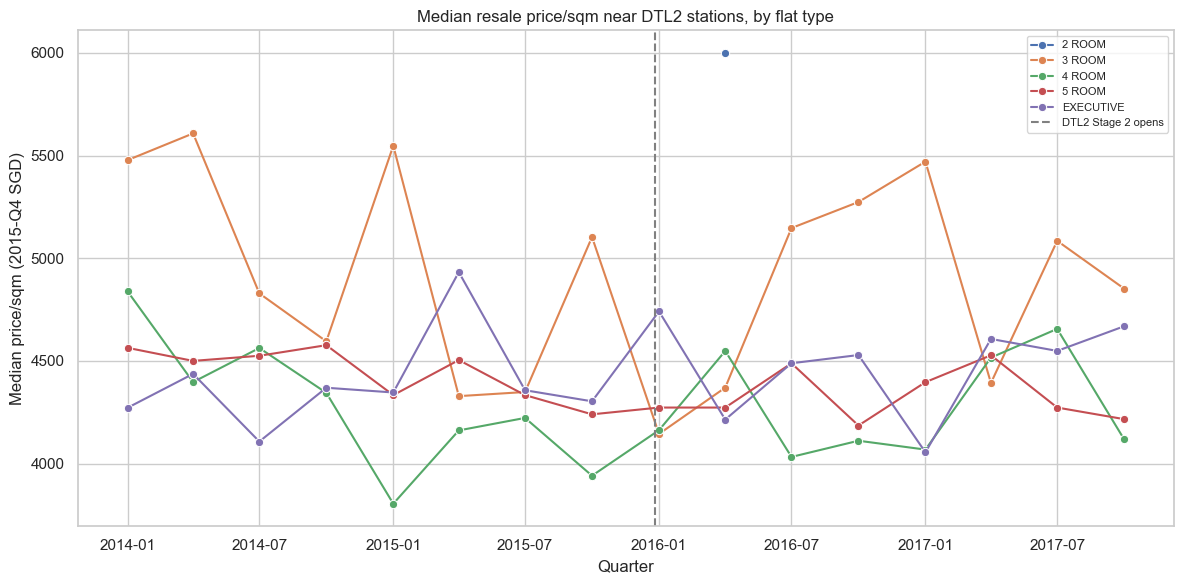

In [61]:
dtl2_sample_filtered["resale_price/sqm"] = dtl2_sample_filtered["resale_price"]/dtl2_sample_filtered["floor_area_sqm"]
quarterly = (
    dtl2_sample_filtered.groupby(["flat_type", "quarter"])["resale_price/sqm"]
    .median()
    .reset_index(name="resale_price/sqm")
)
quarterly["quarter_dt"] = quarterly["quarter"].dt.to_timestamp()

MAIN_FLAT_TYPES = ["2 ROOM", "3 ROOM", "4 ROOM", "5 ROOM", "EXECUTIVE"]
plot_df = quarterly[quarterly["flat_type"].isin(MAIN_FLAT_TYPES)]

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=plot_df, x="quarter_dt", y="resale_price/sqm", hue="flat_type", marker="o", ax=ax)
ax.axvline(pd.Timestamp("2015-12-27"), color="gray", ls="--", lw=1.5, label="DTL2 Stage 2 opens")
ax.set_title("Median resale price/sqm near DTL2 stations, by flat type")
ax.set_xlabel("Quarter")
ax.set_ylabel("Median price/sqm (2015-Q4 SGD)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Step 5b: Validate the control group with a pre-trends check

The control towns (Woodlands, Sembawang, Yishun, Ang Mo Kio) were chosen because they're
comparable outer/suburban estates with no other rail line opening in the same window. The standard validation is a **parallel-trends check**: restrict to the *pre*-treatment period only, and test whether treated and
control were already moving together before DTL2 opened. If they were diverging even before
treatment, the post-period "effect" could just be a continuation of a pre-existing gap, not a DTL2
effect.

Two views of the same check:
1. **Visual** -- plot treated vs. each control town's rescaled price trend, pre-2015-12-27 only.
2. **Formal** -- fit `rescaled_price ~ treated * time_trend + covariates` on the pre-period alone.
   If `treated:time_trend` is statistically indistinguishable from zero, pre-trends are parallel
   (supports the control group choice). A significant coefficient here means treated and control
   were already on different trajectories, and the DiD estimate above would be biased by that
   pre-existing divergence, not just measuring the DTL2 effect.

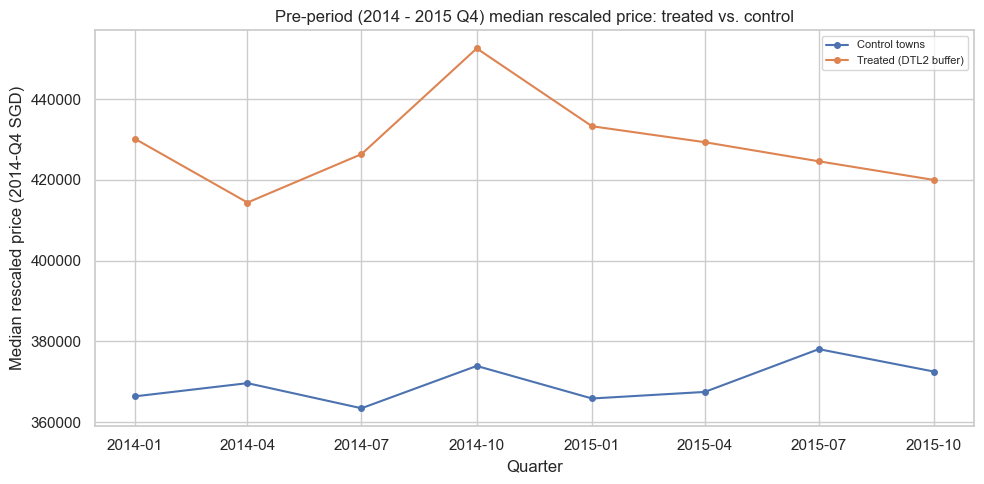

Pre-trend interaction (treated x time): +3,134 SGD/year (p=0.249)
=> No significant pre-trend divergence -- consistent with parallel trends holding.


In [64]:
# Uses the same rescaled/windowed construction as Step 6, but restricted to the pre-period.
PRE_WINDOW_START = pd.Timestamp("2014-01-01")  # slightly wider than 2014 to see more pre-trend

rpi = pd.read_csv(DATA_DIR / "rpi-table.csv")
resale_rescaled_pre = readjust_price(resale, rpi, target_year=2015, target_quarter=4)

pre_treated = resale_rescaled_pre[resale_rescaled_pre["address"].isin(near_addresses["address"])].copy()
pre_treated["treated"] = True

CONTROL_TOWNS = ["WOODLANDS", "SEMBAWANG", "YISHUN", "ANG MO KIO"]
pre_control = resale_rescaled_pre[resale_rescaled_pre["town"].isin(CONTROL_TOWNS)].copy()
pre_control["treated"] = False

pre_sample = pd.concat([pre_treated, pre_control], ignore_index=True)
pre_sample = pre_sample[
    pre_sample["month"].between(PRE_WINDOW_START, pd.Timestamp("2015-12-27"))
].copy()

# --- Visual check ---
pre_sample["quarter"] = pre_sample["month"].dt.to_period("Q")
pre_quarterly = (
    pre_sample.assign(group=np.where(pre_sample["treated"], "Treated (DTL2 buffer)", "Control towns"))
    .groupby(["group", "quarter"])[RESCALED_COL]
    .median()
    .reset_index(name="median_rescaled_price")
)
pre_quarterly["quarter_dt"] = pre_quarterly["quarter"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 5))
for grp, g in pre_quarterly.groupby("group"):
    g = g.sort_values("quarter_dt")
    ax.plot(g["quarter_dt"], g["median_rescaled_price"], marker="o", ms=4, label=grp)
ax.set_title("Pre-period (2014 - 2015 Q4) median rescaled price: treated vs. control")
ax.set_xlabel("Quarter")
ax.set_ylabel("Median rescaled price (2014-Q4 SGD)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# --- Formal check: treated x linear time trend, pre-period only ---
pre_sample["time_trend"] = (
    (pre_sample["month"] - pre_sample["month"].min()) / pd.Timedelta(days=365.25)
)

pretrend_model = smf.ols(
    f"{RESCALED_COL} ~ treated * time_trend + C(flat_type) + floor_area_sqm + C(flat_model) + C(town) + flat_age_years + mid_floor",
    data=pre_sample,
).fit(cov_type="HC1")

interaction_coef = pretrend_model.params["treated[T.True]:time_trend"]
interaction_p = pretrend_model.pvalues["treated[T.True]:time_trend"]
print(f"Pre-trend interaction (treated x time): {interaction_coef:+,.0f} SGD/year (p={interaction_p:.3f})")
if interaction_p < 0.05:
    print("=> Significant pre-trend divergence -- control group may not satisfy parallel trends.")
else:
    print("=> No significant pre-trend divergence -- consistent with parallel trends holding.")

## Step 6: OLS diff-in-diff

Model: `rescaled_price ~ treated + post + did + flat_type + flat_model + floor_area_sqm`, matching
the textbook DiD form `Y = b0 + b1*Time + b2*Intervention + b3*Time*Intervention + b4*Covariates`,
where `post` = Time, `treated` = Intervention, `did` = Time*Intervention (the coefficient of
interest), estimated on prices already rescaled to a 2015-Q4 basis (Step 4) rather than log price --
rescaling removes the market-wide index/time-value-of-money component directly, so a raw-level
outcome is usable here without a separate quarter-FE term absorbing it.

`CUTOFF_DATE` should be set after inspecting the plot in Step 5 -- adjust it if the trend visibly
breaks before/after 2015-12-27 (e.g. an announcement- or construction-driven anticipation effect).

Treated = transactions whose *address* falls inside the 1km DTL2 buffer (`near_addresses`), not
whole towns -- Bukit Panjang, Choa Chu Kang, Bukit Timah etc. each contain many blocks with no real
access to the line, so only the buffered addresses go into the treated group.

Control = all transactions in matched non-DTL2 towns of comparable price tier: Woodlands, Sembawang,
Yishun, Ang Mo Kio, Sengkang. Choa Chu Kang is excluded from the control set even though it's a
comparable outer/suburban town, because ~4,000 CCK transactions actually fall inside the 1km DTL2
buffer (CCK borders Bukit Panjang) -- those are already captured in the treated group via
`near_addresses`, and the remaining CCK addresses are neither treated nor a clean control, so the
town is left out of the sample entirely rather than mislabelled.

Window: 2014-2017, symmetric around the 2015-12-27 opening, for both treated and control.

In [65]:
CUTOFF_DATE = pd.Timestamp("2015-12-27")  # TODO: adjust based on the Step 5 plot if needed
WINDOW_START = pd.Timestamp("2014-01-01")
WINDOW_END = pd.Timestamp("2017-12-31")

CONTROL_TOWNS = ["WOODLANDS", "SEMBAWANG", "YISHUN", "ANG MO KIO"]
# Choa Chu Kang deliberately excluded from control -- part of it falls inside the DTL2 buffer
# (already captured as treated via near_addresses), and the remainder isn't a clean control.

resale_rescaled = readjust_price(resale, rpi, target_year=2015, target_quarter=4)

treated_txns = resale_rescaled[resale_rescaled["address"].isin(near_addresses["address"])].copy()
treated_txns["treated"] = True

control_txns = resale_rescaled[resale_rescaled["town"].isin(CONTROL_TOWNS)].copy()
control_txns["treated"] = False

did_sample = pd.concat([treated_txns, control_txns], ignore_index=True)
did_sample = did_sample[did_sample["month"].between(WINDOW_START, WINDOW_END)].copy()

did_sample["post"] = did_sample["month"] >= CUTOFF_DATE
did_sample["did"] = did_sample["treated"] & did_sample["post"]

print(f"Sample size: {len(did_sample)} ({did_sample['treated'].sum()} treated, "
      f"{(~did_sample['treated']).sum()} control)")

model = smf.ols(
    f"{RESCALED_COL} ~ treated + post + did + C(flat_type) + C(flat_model) + floor_area_sqm + flat_age_years +C(town) + mid_floor",
    data=did_sample,
).fit(cov_type="HC1")

did_coef = model.params["did[T.True]"]
did_p = model.pvalues["did[T.True]"]
print(f"\nDiD coefficient: {did_coef:+,.0f} SGD (p={did_p:.3f})")
model.summary()

Sample size: 17858 (2409 treated, 15449 control)

DiD coefficient: +10,504 SGD (p=0.000)


c:\Users\zheng\anaconda3\envs\nus_odi\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 30, but rank is 28
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     Rescale_price_2015_Q4   R-squared:                       0.865
Model:                               OLS   Adj. R-squared:                  0.865
Method:                    Least Squares   F-statistic:                     2853.
Date:                   Mon, 20 Jul 2026   Prob (F-statistic):               0.00
Time:                           17:42:15   Log-Likelihood:            -2.1480e+05
No. Observations:                  17858   AIC:                         4.297e+05
Df Residuals:                      17829   BIC:                         4.299e+05
Df Model:                             28                                         
Covariance Type:                     HC1                                         
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                           2.982e+05   1.22e+04     24.400      0.000    2.74e+05    3.22e+05
treated[T.True]                     1.291e+04   2198.717      5.870      0.000    8596.256    1.72e+04
post[T.True]                       -1815.0554    624.931     -2.904      0.004   -3039.898    -590.213
did[T.True]                          1.05e+04   2186.493      4.804      0.000    6218.723    1.48e+04
C(flat_type)[T.3 ROOM]              3.282e+04   4100.981      8.003      0.000    2.48e+04    4.09e+04
C(flat_type)[T.4 ROOM]              5.696e+04   5125.767     11.113      0.000    4.69e+04     6.7e+04
C(flat_type)[T.5 ROOM]              5.997e+04   6302.589      9.515      0.000    4.76e+04    7.23e+04
C(flat_type)[T.EXECUTIVE]           9.387e+04   8303.747     11.305      0.000    7.76e+04     1.1e+05
C(flat_type)[T.MULTI-GENERATION]    3.916e+04   8487.645      4.613      0.000    2.25e+04    5.58e+04
C(flat_model)[T.Apartment]          -7.36e+04    1.1e+04     -6.673      0.000   -9.52e+04    -5.2e+04
C(flat_model)[T.DBSS]               8.751e+04   1.23e+04      7.099      0.000    6.33e+04    1.12e+05
C(flat_model)[T.Improved]          -9.768e+04   1.11e+04     -8.820      0.000   -1.19e+05    -7.6e+04
C(flat_model)[T.Maisonette]         -6.59e+04   1.11e+04     -5.923      0.000   -8.77e+04   -4.41e+04
C(flat_model)[T.Model A]           -1.209e+05   1.11e+04    -10.924      0.000   -1.43e+05   -9.92e+04
C(flat_model)[T.Model A2]          -1.194e+05   1.12e+04    -10.693      0.000   -1.41e+05   -9.75e+04
C(flat_model)[T.Multi Generation]   3.916e+04   8487.645      4.613      0.000    2.25e+04    5.58e+04
C(flat_model)[T.New Generation]    -1.125e+05    1.1e+04    -10.199      0.000   -1.34e+05   -9.09e+04
C(flat_model)[T.Premium Apartment] -1.108e+05    1.1e+04    -10.047      0.000   -1.32e+05   -8.92e+04
C(flat_model)[T.Simplified]        -1.192e+05   1.12e+04    -10.664      0.000   -1.41e+05   -9.73e+04
C(flat_model)[T.Standard]          -8.431e+04   1.27e+04     -6.625      0.000   -1.09e+05   -5.94e+04
C(town)[T.BUKIT PANJANG]           -1.072e+05   1883.993    -56.894      0.000   -1.11e+05   -1.03e+05
C(town)[T.BUKIT TIMAH]              1.743e+05   5735.792     30.391      0.000    1.63e+05    1.86e+05
C(town)[T.CENTRAL AREA]             3.776e+04   3870.115      9.756      0.000    3.02e+04    4.53e+04
C(town)[T.CHOA CHU KANG]           -1.401e+05   2240.462    -62.554      0.000   -1.45e+05   -1.36e+05
C(town)[T.KALLANG/WHAMPOA]          4.817e+04   3083.798     15.619      0.000    4.21e+04    5.42e+04
C(town)[T.SEMBAWANG]               -1.444e+05   2308.390    -62.558      0.000   -1.49e+05    -1.4e+05
C(town)[T.WOODLANDS]               -1.282e+05   1876.907    -68